# ThessLink RL — Training Notebook

Εκπαίδευση και αξιολόγηση των αλγορίθμων **Q-Learning**, **DQN**, **PPO** σε grids 8×8, 32×32, 64×64.

| Grid | Q-Learning | DQN | PPO |
|------|-----------|-----|-----|
| 8×8  | `nav_qtable_8.pkl` | `nav_dqn_8.zip` | `nav_ppo_8.zip` |
| 32×32 | `nav_qtable_32.pkl` | `nav_dqn_32.zip` | `nav_ppo_32.zip` |
| 64×64 | `nav_qtable_64.pkl` | `nav_dqn_64.zip` | `nav_ppo_64.zip` |

In [1]:
import sys
from pathlib import Path

# Make sure the project root and lb-foraging are on the path
ROOT = Path(".").resolve()
LBF = ROOT / "lb-foraging"
for p in [str(ROOT), str(LBF)]:
    if p not in sys.path:
        sys.path.insert(0, p)

print("Project root:", ROOT)

Project root: /Users/stanimeros/Documents/projects/thesslink-rl


In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from IPython.display import display, Image

from navigation_train import (
    train_ppo, train_dqn, train_qlearning,
    _eval_navigation, _discretize_nav, _NAV_ACTIONS,
    MODEL_DIR,
)
from poi_environment import PoINavigationEnv

print("Imports OK")

Imports OK


---
## Βοηθητικές συναρτήσεις

In [ ]:
import pickle

GRID_SIZES = [8]
ALGOS = ["ppo", "dqn", "qlearning"]


def get_history_path(algo: str, grid_size: int | str):
    """Path to training_history_*.pkl in the model folder."""
    return MODEL_DIR / algo / f"training_history_{algo}_{str(grid_size)}.pkl"


def get_plot_path(algo: str, grid_size: int | str):
    """Path to training_plot_*.png in the model folder."""
    return MODEL_DIR / algo / f"training_plot_{algo}_{str(grid_size)}.png"


def model_exists(algo: str, grid_size: int) -> bool:
    """Check if a trained model file exists."""
    tag = str(grid_size)
    if algo == "ppo":
        return (MODEL_DIR / "ppo" / f"nav_ppo_{tag}.zip").exists()
    elif algo == "dqn":
        return (MODEL_DIR / "dqn" / f"nav_dqn_{tag}.zip").exists()
    else:
        return (MODEL_DIR / "qlearning" / f"nav_qtable_{tag}.pkl").exists()


def history_exists(algo: str, grid_size: int) -> bool:
    """Check if training_history_*.pkl exists (source for plot generation)."""
    return get_history_path(algo, grid_size).exists()


def show_status():
    """Print a table showing which models and plots exist."""
    header = f"{'':12}" + "".join(f"{g:>8}" for g in GRID_SIZES)
    print(header)
    print("-" * (12 + 8 * len(GRID_SIZES)))
    for algo in ALGOS:
        row = f"{algo:<12}"
        for g in GRID_SIZES:
            m = "M" if model_exists(algo, g) else "."
            p = "H" if history_exists(algo, g) else "."
            row += f"  [{m}{p}]  "
        print(row)
    print("\nM=model exists  H=history (.pkl) exists  .=missing")


show_status()

                   8      32      64
------------------------------------
ppo           [MH]    [..]    [..]  
dqn           [MH]    [..]    [..]  
qlearning     [MH]    [..]    [..]  

M=model exists  H=history (.pkl) exists  .=missing


---
## Training

**Focus: 8×8 first** — optimize & validate before scaling to 64×64.

**Policy chooses target:** Action = target_idx*5 + move. Policy picks cost-optimal POI and navigates. Obs: 19 floats. Agreement = policy target vs cost-optimal baseline.

Επίλεξε αλγόριθμο και grid size και τρέξε το αντίστοιχο cell.

> **Steps/episodes για ~5 λεπτά training ανά grid (εκτίμηση):**
> | Grid | PPO steps | DQN steps | Q-Learning episodes |
> |------|-----------|-----------|--------------------|
> | 8×8  | 100 000   | 100 000   | 50 000 (only)      |
> | 32×32 | 80 000   | 80 000    | —                  |
> | 64×64 | 150 000  | 150 000   | —                  |
>
> Οι τιμές αυτές είναι **προεπιλεγμένες** στα training cells παρακάτω.

### PPO

In [4]:
_PPO_STEPS = {8: 200_000, 32: 200_000, 64: 200_000}

GRID = 8   # ← αλλαγή: 8, 32, ή 64
STEPS = _PPO_STEPS[GRID]

train_ppo(
    total_timesteps=STEPS,
    seed=42,
    eval_freq=max(STEPS // 20, 1000),
    grid_size=(GRID, GRID),
)
show_status()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
-----------------------------
| time/              |      |
|    fps             | 3721 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 128  |
-----------------------------
-------------------------------------------
| rollout/                |               |
|    ep_len_mean          | 193           |
|    ep_rew_mean          | -85.4         |
| time/                   |               |
|    fps                  | 2596          |
|    iterations           | 2             |
|    time_elapsed         | 0             |
|    total_timesteps      | 256           |
| train/                  |               |
|    approx_kl            | 0.00032534264 |
|    clip_fraction        | 0             |
|    clip_range           | 0.2           |
|    clip_range_vf        | 10            |
|    entropy_loss         | -2.71         |
|    explained_variance   | -0.0124 

### DQN

In [5]:
_DQN_STEPS = {8: 200_000, 32: 200_000, 64: 200_000}

GRID = 8   # ← αλλαγή: 8, 32, ή 64
STEPS = _DQN_STEPS[GRID]

train_dqn(
    total_timesteps=STEPS,
    seed=42,
    eval_freq=max(STEPS // 20, 1000),
    grid_size=(GRID, GRID),
)
show_status()

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 131      |
|    ep_rew_mean      | -53.2    |
|    exploration_rate | 0.975    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 23831    |
|    time_elapsed     | 0        |
|    total_timesteps  | 524      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 148      |
|    ep_rew_mean      | -63.1    |
|    exploration_rate | 0.944    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 16616    |
|    time_elapsed     | 0        |
|    total_timesteps  | 1181     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.0366   |
|    n_updates        | 45       |
-------------------------------

### Q-Learning

In [6]:
EPISODES = 5_000
GRID = 8

train_qlearning(
    total_episodes=EPISODES,
    seed=42,
    eval_freq=max(EPISODES // 20, 5000),
    grid_size=(GRID, GRID),
)
show_status()

Training Q-Learning (navigation, 8x8) for 5000 episodes...
  Episode     5000: reward=-77.515  cost_success=62.3%  ε=0.9512
Saved Q-table to /Users/stanimeros/Documents/projects/thesslink-rl/models/qlearning/nav_qtable_8.pkl
Saved history to /Users/stanimeros/Documents/projects/thesslink-rl/models/qlearning/training_history_qlearning_8.pkl
Final eval — cost_success: 62.5%  reward: -77.373  agreement: 43.4%
                   8      32      64
------------------------------------
ppo           [MH]    [..]    [..]  
dqn           [MH]    [..]    [..]  
qlearning     [MH]    [..]    [..]  

M=model exists  H=history (.pkl) exists  .=missing


---
## Εμφάνιση Plots

### Ένα συγκεκριμένο plot

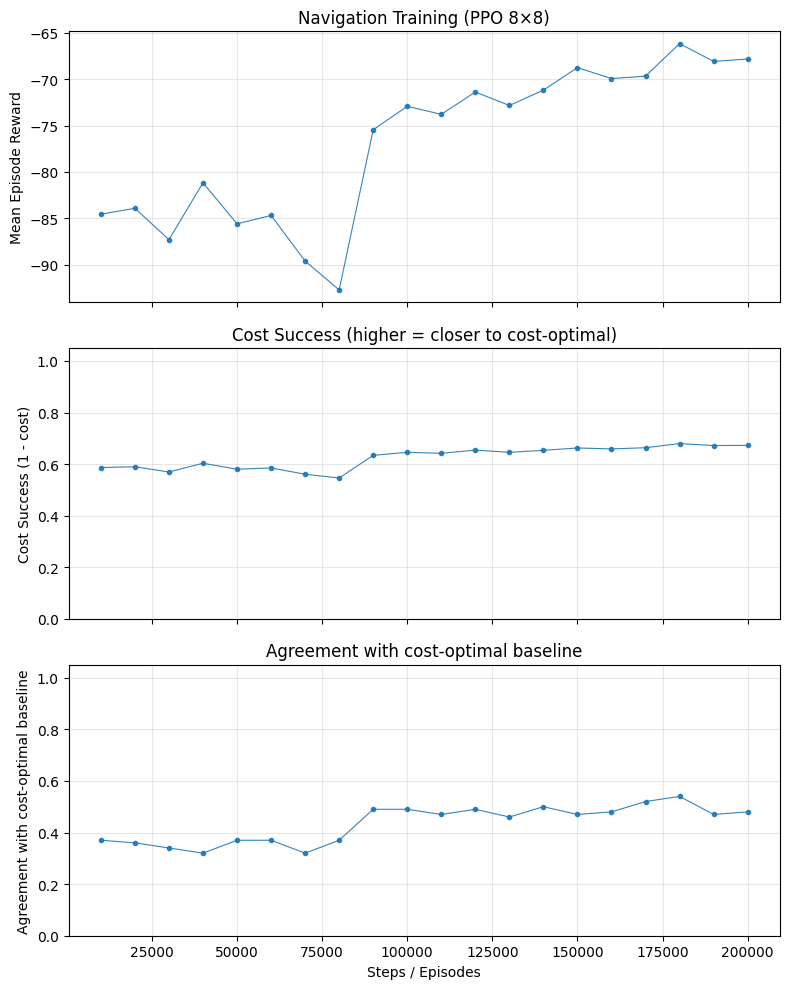

In [7]:
ALGO = "ppo"   # ← ppo, dqn, qlearning
GRID = 8       # ← 8, 32, 64

ALGO_CONFIG = {"ppo": ("PPO", "tab:blue"), "dqn": ("DQN", "tab:green"), "qlearning": ("Q-Learning", "tab:orange")}
path = get_history_path(ALGO, GRID)
if path.exists():
    with open(path, "rb") as f:
        data = pickle.load(f)
    title, color = ALGO_CONFIG[ALGO]
    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
    steps, rewards, cost_success, agreement = data["steps"], data["rewards"], data["cost_success"], data["agreement"]
    axes[0].plot(steps, rewards, color=color, linewidth=0.8, alpha=0.9, marker="o", markersize=3)
    axes[0].set_ylabel("Mean Episode Reward")
    axes[0].set_title(f"Navigation Training ({title} {GRID}×{GRID})")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(steps, cost_success, color=color, linewidth=0.8, alpha=0.9, marker="o", markersize=3)
    axes[1].set_ylabel("Cost Success (1 - cost)")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Cost Success (higher = closer to cost-optimal)")
    axes[1].grid(True, alpha=0.3)
    axes[2].plot(steps, agreement, color=color, linewidth=0.8, alpha=0.9, marker="o", markersize=3)
    axes[2].set_ylabel("Agreement with cost-optimal baseline")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_xlabel("Steps / Episodes")
    axes[2].set_title("Agreement with cost-optimal baseline")
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plot_path = get_plot_path(ALGO, GRID)
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print(f"History not found: {path}. Run {ALGO} training first.")

### Σύγκριση PPO, DQN, Q-Learning (combined)

Όλα τα τρία μοντέλα σε ένα figure. Απαιτεί `training_history_*.pkl` από προηγούμενα training runs.

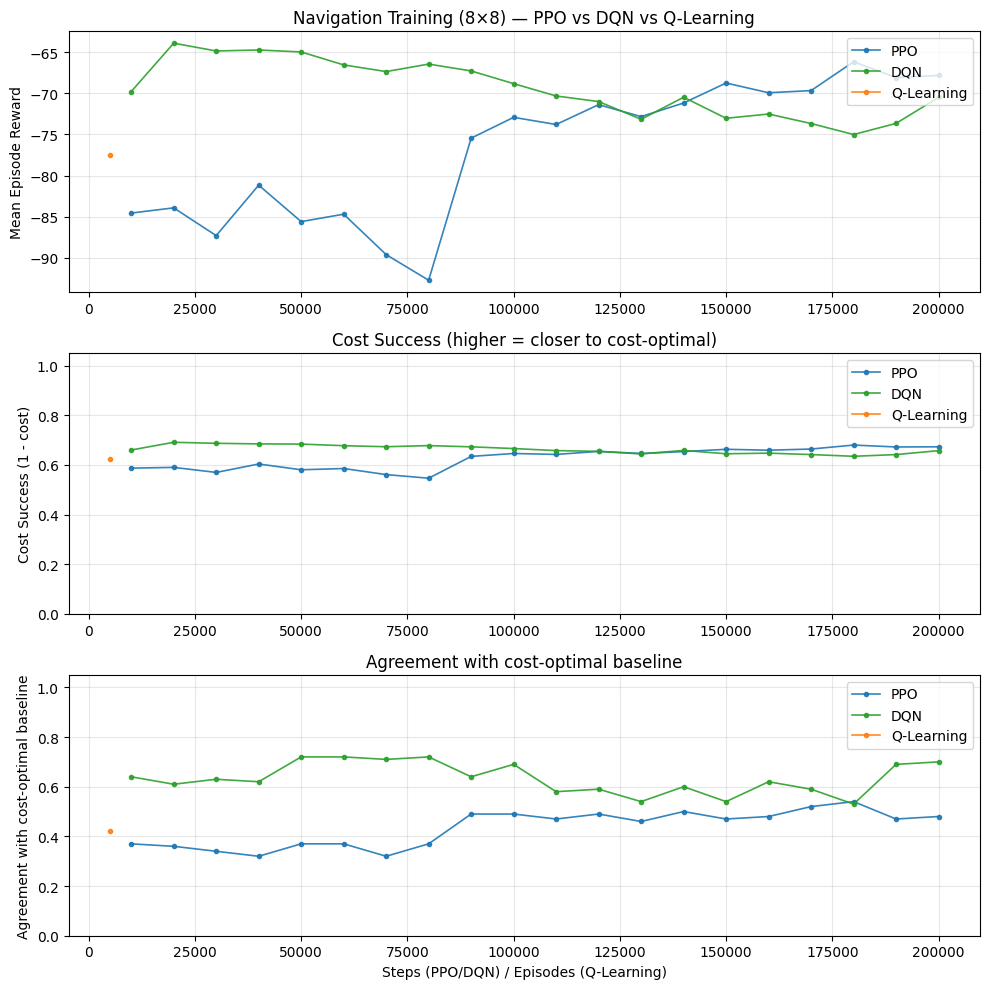

In [8]:
GRID = 8   # ← 8, 32, 64

algo_configs = [("ppo", "PPO", "tab:blue"), ("dqn", "DQN", "tab:green"), ("qlearning", "Q-Learning", "tab:orange")]
histories = {}
for algo, label, color in algo_configs:
    path = get_history_path(algo, GRID)
    if path.exists():
        with open(path, "rb") as f:
            histories[algo] = {"label": label, "color": color, **pickle.load(f)}
    else:
        print(f"  Skipping {label}: {path} not found")

if histories:
    fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=False)
    for algo, data in histories.items():
        steps = data["steps"]
        axes[0].plot(steps, data["rewards"], color=data["color"], linewidth=1.2, alpha=0.9, label=data["label"], marker="o", markersize=3)
        axes[1].plot(steps, data["cost_success"], color=data["color"], linewidth=1.2, alpha=0.9, label=data["label"], marker="o", markersize=3)
        axes[2].plot(steps, data["agreement"], color=data["color"], linewidth=1.2, alpha=0.9, label=data["label"], marker="o", markersize=3)
    axes[0].set_ylabel("Mean Episode Reward")
    axes[0].set_title(f"Navigation Training ({GRID}×{GRID}) — PPO vs DQN vs Q-Learning")
    axes[0].legend(loc="upper right")
    axes[0].grid(True, alpha=0.3)
    axes[1].set_ylabel("Cost Success (1 - cost)")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_title("Cost Success (higher = closer to cost-optimal)")
    axes[1].legend(loc="upper right")
    axes[1].grid(True, alpha=0.3)
    axes[2].set_ylabel("Agreement with cost-optimal baseline")
    axes[2].set_ylim(0, 1.05)
    axes[2].set_xlabel("Steps (PPO/DQN) / Episodes (Q-Learning)")
    axes[2].set_title("Agreement with cost-optimal baseline")
    axes[2].legend(loc="upper right")
    axes[2].grid(True, alpha=0.3)
    plt.tight_layout()
    plot_path = MODEL_DIR / f"training_plot_combined_{GRID}.png"
    plot_path.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Run PPO, DQN, Q-Learning first to generate training histories.")

### Όλα τα plots — grid 3×3 (αλγόριθμος × grid size)

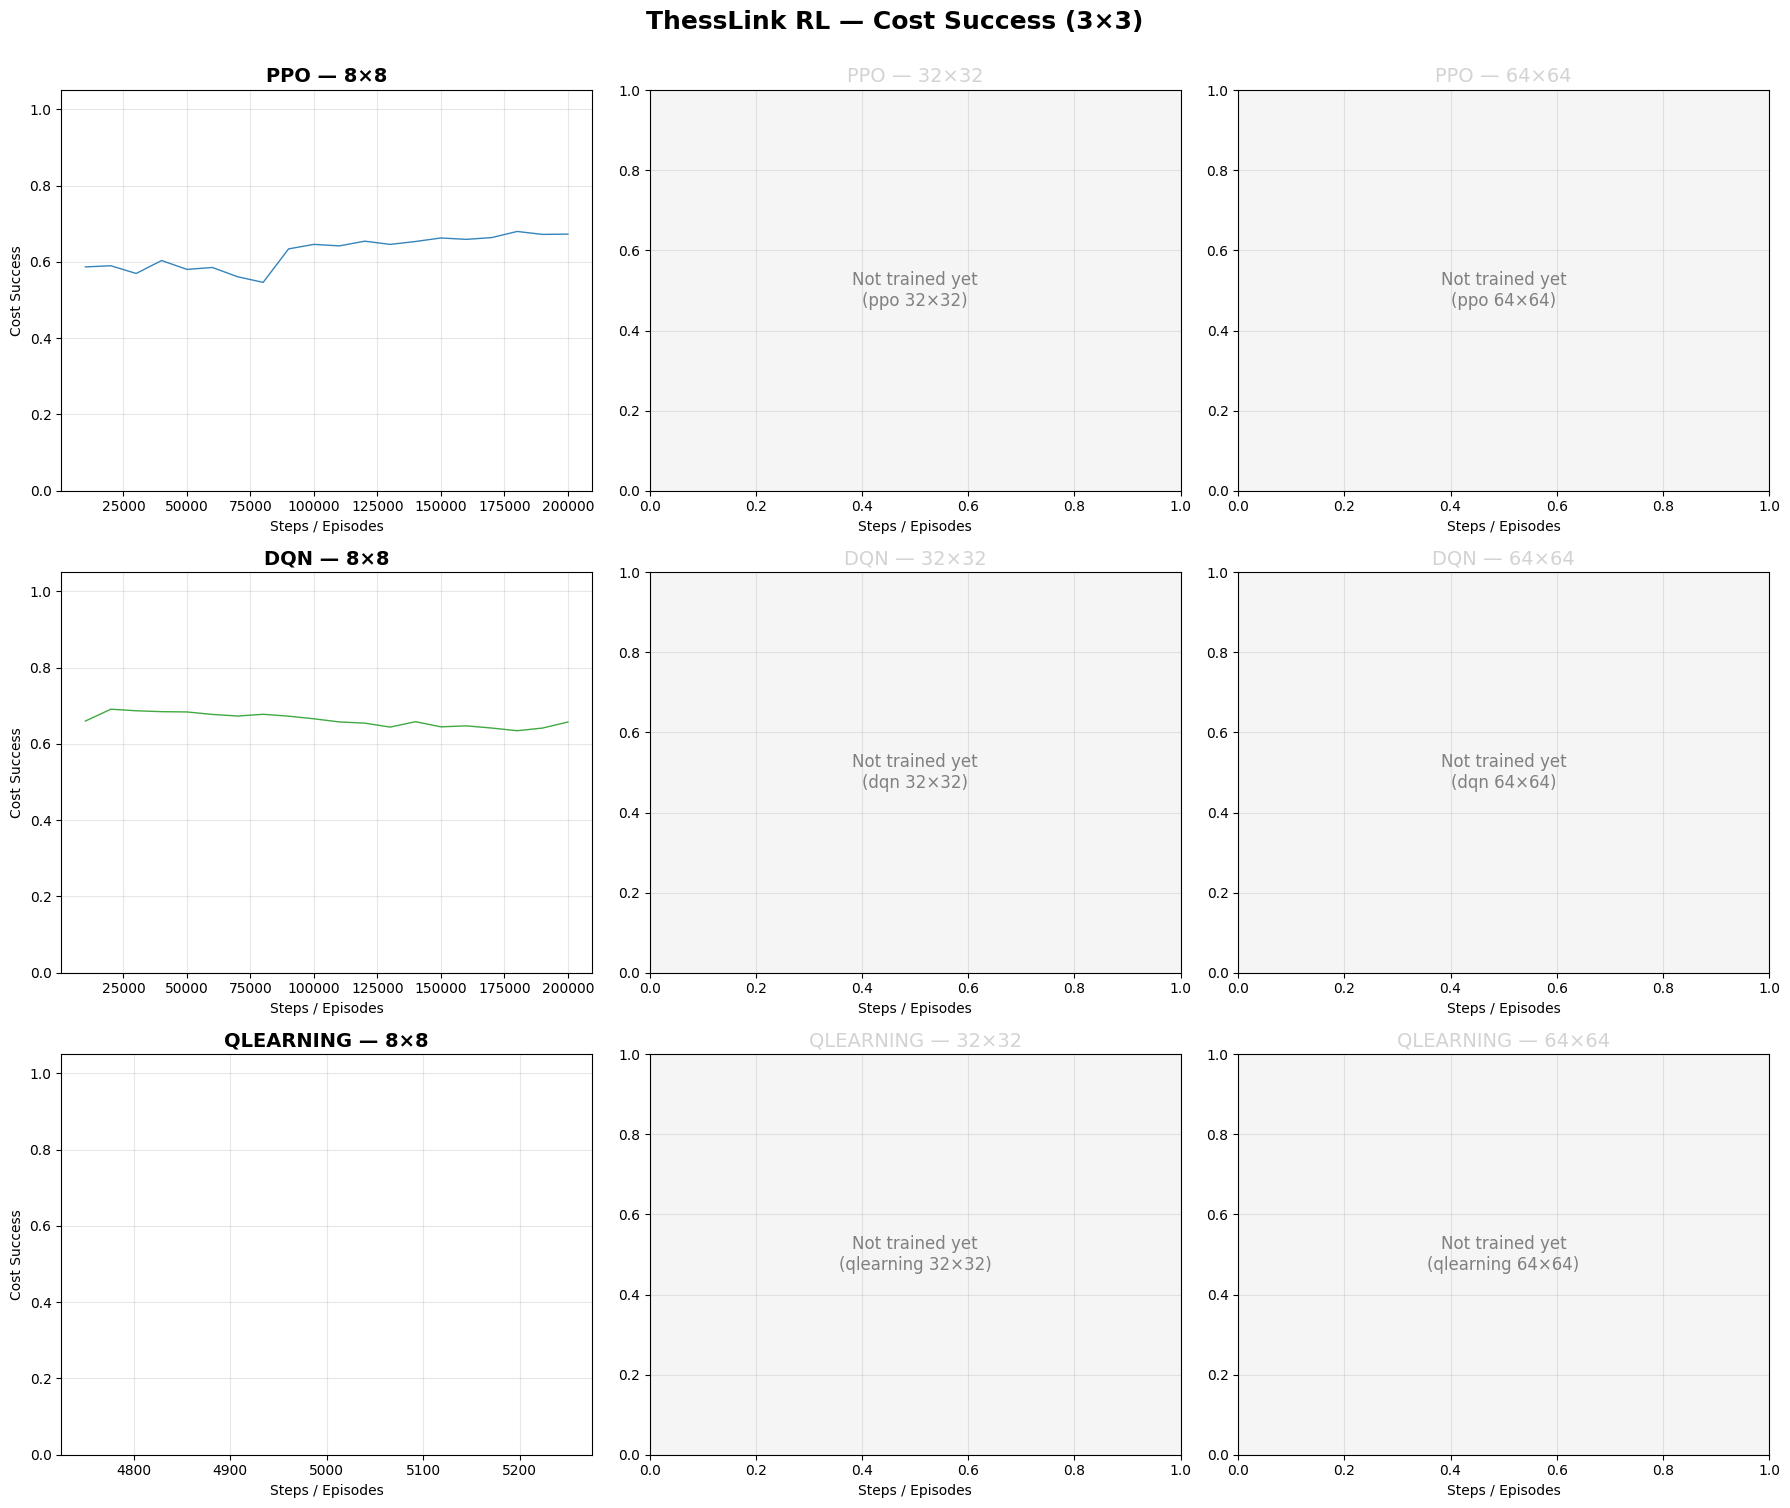

In [9]:
fig, axes = plt.subplots(
    len(ALGOS), len(GRID_SIZES),
    figsize=(6 * len(GRID_SIZES), 5 * len(ALGOS)),
)

colors = {"ppo": "tab:blue", "dqn": "tab:green", "qlearning": "tab:orange"}
for row, algo in enumerate(ALGOS):
    for col, grid in enumerate(GRID_SIZES):
        ax = axes[row][col]
        path = get_history_path(algo, grid)
        if path.exists():
            with open(path, "rb") as f:
                data = pickle.load(f)
            ax.plot(data["steps"], data["cost_success"], color=colors[algo], linewidth=1, alpha=0.9)
            ax.set_ylim(0, 1.05)
            ax.set_ylabel("Cost Success")
            ax.set_title(f"{algo.upper()} — {grid}×{grid}", fontsize=14, fontweight="bold")
        else:
            ax.text(0.5, 0.5, f"Not trained yet\n({algo} {grid}×{grid})",
                    ha="center", va="center", fontsize=12, color="gray",
                    transform=ax.transAxes)
            ax.set_facecolor("#f5f5f5")
            ax.set_title(f"{algo.upper()} — {grid}×{grid}", fontsize=14, color="lightgray")
        ax.grid(True, alpha=0.3)
        ax.set_xlabel("Steps / Episodes")

plt.suptitle("ThessLink RL — Cost Success (3×3)", fontsize=18, fontweight="bold", y=1.002)
plt.tight_layout()
plot_path = MODEL_DIR / "training_plot_grid.png"
plot_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(plot_path, dpi=150, bbox_inches="tight")
plt.show()

---
## Αξιολόγηση (Evaluation)

### Ένα μοντέλο

In [10]:
ALGO = "ppo"   # ← ppo, dqn, qlearning
GRID = 8       # ← 8, 32, 64
N_EPISODES = 200

tag = str(GRID)
grid_size = (GRID, GRID)

if not model_exists(ALGO, GRID):
    print(f"Model not found: {ALGO} {GRID}×{GRID}. Train it first.")
else:
    if ALGO == "ppo":
        from stable_baselines3 import PPO
        m = PPO.load(str(MODEL_DIR / "ppo" / f"nav_ppo_{tag}"))
        predict = lambda obs: int(m.predict(obs, deterministic=True)[0])
    elif ALGO == "dqn":
        from stable_baselines3 import DQN
        m = DQN.load(str(MODEL_DIR / "dqn" / f"nav_dqn_{tag}"))
        predict = lambda obs: int(m.predict(obs, deterministic=True)[0])
    else:
        with open(MODEL_DIR / "qlearning" / f"nav_qtable_{tag}.pkl", "rb") as f:
            q_table = pickle.load(f)
        predict = lambda obs: int(np.argmax(q_table.get(_discretize_nav(obs), np.zeros(_NAV_ACTIONS))))

    stats = _eval_navigation(predict, n_episodes=N_EPISODES, grid_size=grid_size)
    print(f"\n{'='*40}")
    print(f"  {ALGO.upper()} — {GRID}×{GRID} ({N_EPISODES} episodes)")
    print(f"{'='*40}")
    print(f"  Cost success : {stats['cost_success']:.1%}")
    print(f"  Mean reward  : {stats['mean_reward']:.4f}")
    print(f"  Mean steps   : {stats['mean_steps']:.1f}")
    print(f"  Agreement    : {stats['agreement']:.1%}")


  PPO — 8×8 (200 episodes)
  Cost success : 68.1%
  Mean reward  : -66.0002
  Mean steps   : 200.0
  Agreement    : 49.5%


### Σύγκριση όλων των μοντέλων (πίνακας)

In [11]:
N_EPISODES = 100  # ← μειώστε για ταχύτητα

results = []

for algo in ALGOS:
    for grid in GRID_SIZES:
        tag = str(grid)
        grid_size = (grid, grid)
        if not model_exists(algo, grid):
            results.append({"algo": algo, "grid": grid, "status": "not trained",
                            "success": None, "reward": None, "steps": None, "agreement": None})
            continue

        print(f"Evaluating {algo.upper()} {grid}×{grid}...", end=" ", flush=True)
        if algo == "ppo":
            from stable_baselines3 import PPO
            m = PPO.load(str(MODEL_DIR / "ppo" / f"nav_ppo_{tag}"))
            predict = lambda obs, _m=m: int(_m.predict(obs, deterministic=True)[0])
        elif algo == "dqn":
            from stable_baselines3 import DQN
            m = DQN.load(str(MODEL_DIR / "dqn" / f"nav_dqn_{tag}"))
            predict = lambda obs, _m=m: int(_m.predict(obs, deterministic=True)[0])
        else:
            with open(MODEL_DIR / "qlearning" / f"nav_qtable_{tag}.pkl", "rb") as f:
                qt = pickle.load(f)
            predict = lambda obs, _qt=qt: int(np.argmax(_qt.get(_discretize_nav(obs), np.zeros(_NAV_ACTIONS))))

        stats = _eval_navigation(predict, n_episodes=N_EPISODES, grid_size=grid_size)
        results.append({"algo": algo, "grid": grid, "status": "ok",
                        "success": stats["cost_success"], "reward": stats["mean_reward"],
                        "steps": stats["mean_steps"], "agreement": stats["agreement"]})
        print(f"success={stats['cost_success']:.1%}")

# Pretty table
print(f"\n{'Algo':<12} {'Grid':>6} {'Success':>9} {'Reward':>9} {'Steps':>8} {'Agreement':>11}")
print("-" * 60)
for r in results:
    if r["status"] == "not trained":
        print(f"{r['algo']:<12} {r['grid']:>4}×{r['grid']:<4}  {'(not trained)':>40}")
    else:
        print(f"{r['algo']:<12} {r['grid']:>4}×{r['grid']:<4}  "
              f"{r['success']:>8.1%}  {r['reward']:>9.4f}  {r['steps']:>7.1f}  {r['agreement']:>10.1%}")

Evaluating PPO 8×8... success=68.0%
Evaluating DQN 8×8... success=65.0%
Evaluating QLEARNING 8×8... success=62.3%

Algo           Grid   Success    Reward    Steps   Agreement
------------------------------------------------------------
ppo             8×8        68.0%   -66.3858    200.0       50.0%
ppo            32×32                               (not trained)
ppo            64×64                               (not trained)
dqn             8×8        65.0%   -72.1166    200.0       70.0%
dqn            32×32                               (not trained)
dqn            64×64                               (not trained)
qlearning       8×8        62.3%   -77.5150    200.0       42.0%
qlearning      32×32                               (not trained)
qlearning      64×64                               (not trained)


### Σύγκριση success rate — bar chart

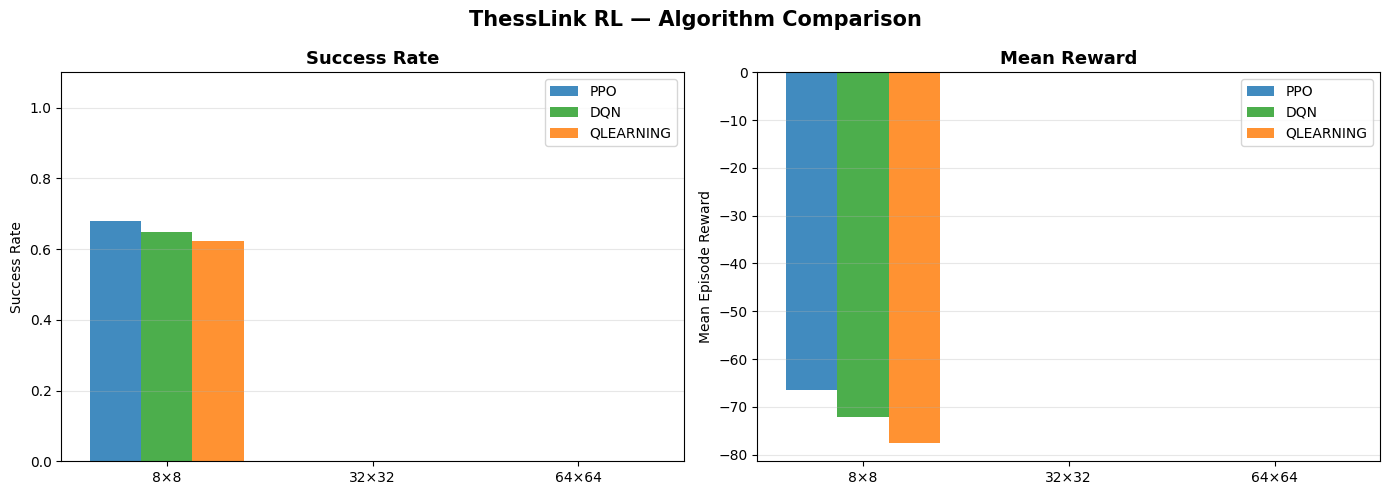

In [12]:
trained = [r for r in results if r["status"] == "ok"]

if not trained:
    print("Δεν υπάρχουν trained models για σύγκριση.")
else:
    algo_colors = {"ppo": "tab:blue", "dqn": "tab:green", "qlearning": "tab:orange"}
    x = np.arange(len(GRID_SIZES))
    width = 0.25

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for i, algo in enumerate(ALGOS):
        vals_success = []
        vals_reward = []
        for grid in GRID_SIZES:
            r = next((r for r in trained if r["algo"] == algo and r["grid"] == grid), None)
            vals_success.append(r["success"] if r else 0)
            vals_reward.append(r["reward"] if r else 0)

        offset = (i - 1) * width
        axes[0].bar(x + offset, vals_success, width, label=algo.upper(),
                    color=algo_colors[algo], alpha=0.85)
        axes[1].bar(x + offset, vals_reward, width, label=algo.upper(),
                    color=algo_colors[algo], alpha=0.85)

    axes[0].set_title("Success Rate", fontsize=13, fontweight="bold")
    axes[0].set_ylabel("Success Rate")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels([f"{g}×{g}" for g in GRID_SIZES])
    axes[0].set_ylim(0, 1.1)
    axes[0].legend()
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].set_title("Mean Reward", fontsize=13, fontweight="bold")
    axes[1].set_ylabel("Mean Episode Reward")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels([f"{g}×{g}" for g in GRID_SIZES])
    axes[1].legend()
    axes[1].grid(axis="y", alpha=0.3)

    plt.suptitle("ThessLink RL — Algorithm Comparison", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()